# PastureIQ — Weather EDA (Mini-Project 1)

## Business problem

Small New Zealand hill-country sheep and beef farmers make stock buy/sell decisions largely on gut feel. Those decisions hinge on **pasture** — how much feed the land is growing — and pasture is driven by **weather**: temperature, rainfall, and evapotranspiration. There is no free, data-driven tool that helps a time-poor farmer see when pasture conditions are tightening or easing.

**PastureIQ** aims to fill that gap. This notebook is the first step: a clean exploration of the *weather foundation* the whole tool will be built on, across three North Island regions.

## What this notebook does

1. Loads daily weather data (2015–2026) for three target regions and verifies its quality.
2. Explores the data along three axes: **region vs region**, **time vs time**, and **variable vs variable**.
3. Engineers a small number of agronomically meaningful features (growing degree days, rainfall deficit, rolling ET0) that preview the pasture-growth modelling in the next phase.

## Questions this notebook answers

1. **How do the three regions differ in their weather profile** — or are they effectively the same?
2. **When in the year does each region come under water stress** (evaporation outpacing rainfall)?
3. **Are dry years a local or a shared event** — does a drought hit one region or all three at once?

The conclusion returns to each of these by number.

## Data source

Historical daily weather from **Open-Meteo** (ERA5 archive). Variables: max/min temperature (°C), precipitation (mm), reference evapotranspiration ET0 (mm), max wind speed (km/h). Licence: data is CC BY 4.0 (attribution: *Weather data from Open-Meteo.com, CC BY 4.0*).

## Regions

| Region | Area | File |
|---|---|---|
| Waikato | South Waikato / King Country hill country | `weather_waikato.csv` |
| Taranaki | South Taranaki / N. Whanganui hill country | `weather_taranaki.csv` |
| Auckland | West Auckland lifestyle blocks | `weather_auckland.csv` |

---
## Phase 1 — Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- Adjust this path if your notebook is not run from the project root ---
DATA_DIR = '../data/raw/weather'

REGIONS = {
    'Waikato':  'weather_waikato.csv',
    'Taranaki': 'weather_taranaki.csv',
    'Auckland': 'weather_auckland.csv',
}

# Expected columns from the Open-Meteo pull (excluding the date column)
WEATHER_VARS = [
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation_sum',
    'et0_fao_evapotranspiration',
    'windspeed_10m_max',
]

In [2]:
def load_region(name, filename):
    """Load one region's weather CSV, parse dates, tag with region name."""
    df = pd.read_csv(f'{DATA_DIR}/{filename}')
    # Open-Meteo's date column is usually 'time' or 'date' — handle both.
    date_col = 'time' if 'time' in df.columns else 'date'
    df = df.rename(columns={date_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df['region'] = name
    return df

frames = {name: load_region(name, fn) for name, fn in REGIONS.items()}
weather = pd.concat(frames.values(), ignore_index=True)
weather.head()

,date,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,windspeed_10m_max,region
0,2015-01-01,20.8,14.0,5.6,4.83,19.7,Waikato
1,2015-01-02,20.7,13.4,0.0,3.57,12.6,Waikato
2,2015-01-03,23.7,11.9,0.2,4.70,9.8,Waikato
3,2015-01-04,23.0,13.3,0.3,4.50,13.0,Waikato
4,2015-01-05,22.4,13.2,0.0,5.06,14.0,Waikato


### Data quality check

Before any analysis, re-verify the claims from the data pull *inside the notebook*: row counts, date ranges, and missing values per region. Never trust an earlier verification blindly.

In [3]:
for name, df in frames.items():
    print(f'{name:10s} | rows: {len(df):5d} | '
          f'{df["date"].min().date()} to {df["date"].max().date()} | '
          f'missing values: {df[WEATHER_VARS].isna().sum().sum()}')

print('\nMissing values by column (all regions combined):')
print(weather[WEATHER_VARS].isna().sum())

Waikato    | rows:  4177 | 2015-01-01 to 2026-06-08 | missing values: 0
Taranaki   | rows:  4177 | 2015-01-01 to 2026-06-08 | missing values: 0
Auckland   | rows:  4177 | 2015-01-01 to 2026-06-08 | missing values: 0

Missing values by column (all regions combined):
temperature_2m_max            0
temperature_2m_min            0
precipitation_sum             0
et0_fao_evapotranspiration    0
windspeed_10m_max             0
dtype: int64


In [4]:
# Add calendar helper columns for time-based grouping
weather['year']  = weather['date'].dt.year
weather['month'] = weather['date'].dt.month

# NZ meteorological seasons (Southern Hemisphere)
season_map = {12: 'Summer', 1: 'Summer', 2: 'Summer',
              3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
              6: 'Winter', 7: 'Winter', 8: 'Winter',
              9: 'Spring', 10: 'Spring', 11: 'Spring'}
weather['season'] = weather['month'].map(season_map)

weather[['date', 'region', 'year', 'month', 'season']].head()

,date,region,year,month,season
0,2015-01-01,Waikato,2015,1,Summer
1,2015-01-02,Waikato,2015,1,Summer
2,2015-01-03,Waikato,2015,1,Summer
3,2015-01-04,Waikato,2015,1,Summer
4,2015-01-05,Waikato,2015,1,Summer


In [5]:
# Summary statistics per region — a first feel for the data
weather.groupby('region')[WEATHER_VARS].describe().T

region                               Auckland     Taranaki      Waikato
temperature_2m_max         count  4177.000000  4177.000000  4177.000000
                           mean     17.936533    16.113431    17.403831
                           std       3.603731     4.227060     4.115502
                           min       7.800000     4.400000     5.900000
                           25%      14.900000    12.800000    14.000000
                           50%      17.700000    15.700000    17.000000
                           75%      20.900000    19.500000    20.800000
                           max      27.500000    29.200000    29.100000
temperature_2m_min         count  4177.000000  4177.000000  4177.000000
                           mean     12.614556     8.560259     9.473617
                           std       3.392024     4.003598     4.194698
                           min       2.800000    -4.200000    -2.400000
                           25%      10.200000     5.900000     6.600000
                           50%      12.600000     8.700000     9.600000
                           75%      15.300000    11.400000    12.600000
                           max      22.500000    19.700000    20.400000
precipitation_sum          count  4177.000000  4177.000000  4177.000000
                           mean      4.084726     3.711180     4.101867
                           std       7.905046     7.106853     8.429544
                           min       0.000000     0.000000     0.000000
                           25%       0.000000     0.000000     0.000000
                           50%       0.800000     0.700000     0.500000
                           75%       4.100000     4.300000     3.900000
                           max     108.300000    79.200000    88.100000
et0_fao_evapotranspiration count  4177.000000  4177.000000  4177.000000
                           mean      2.694898     2.215698     2.334891
                           std       1.292997     1.248165     1.316306
                           min       0.250000     0.230000     0.290000
                           25%       1.630000     1.160000     1.220000
                           50%       2.490000     1.920000     2.020000
                           75%       3.740000     3.110000     3.330000
                           max       6.200000     6.070000     6.430000
windspeed_10m_max          count  4177.000000  4177.000000  4177.000000
                           mean     23.165214    21.959253    20.282452
                           std       8.826504     7.739983     7.475452
                           min       5.500000     5.900000     4.600000
                           25%      16.300000    16.100000    14.700000
                           50%      22.000000    21.000000    19.400000
                           75%      28.800000    27.100000    25.000000
                           max      55.200000    56.100000    54.200000

> **Finding (fill in):** _One plain-language sentence on what the summary stats show — e.g. which region is wettest, which has the widest temperature range._

---
## Phase 2 — Exploratory analysis

Three comparison axes: region vs region, time vs time, variable vs variable.

### Axis 1 — Region vs region

How do the three regions differ in their core weather profile?

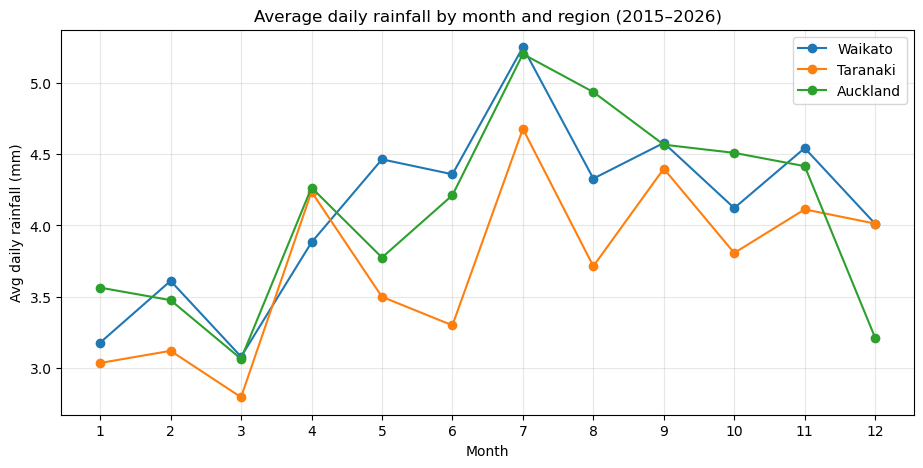

In [6]:
# Average monthly rainfall by region — the seasonal water-supply signal
monthly_rain = (weather.groupby(['region', 'month'])['precipitation_sum']
                       .mean().reset_index())

fig, ax = plt.subplots()
for name in REGIONS:
    sub = monthly_rain[monthly_rain['region'] == name]
    ax.plot(sub['month'], sub['precipitation_sum'], marker='o', label=name)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Avg daily rainfall (mm)')
ax.set_title('Average daily rainfall by month and region (2015–2026)')
ax.legend()
plt.show()

In [7]:
# Annual average of each variable, side by side per region
region_means = weather.groupby('region')[WEATHER_VARS].mean()
region_means

,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,windspeed_10m_max
region,,,,,
Auckland,17.936533,12.614556,4.084726,2.694898,23.165214
Taranaki,16.113431,8.560259,3.711180,2.215698,21.959253
Waikato,17.403831,9.473617,4.101867,2.334891,20.282452


> **Finding :** Tranaki is the driest, while Auckland and Waikato share spots of the wettest, which tracks as they are closer and have more silmilar geography. 

In [8]:
# --- Question 1, tested formally ---
# The charts suggest Taranaki is drier than Auckland. Is that a real
# difference, or just noise? A two-sample t-test settles it.
#
# H0: no difference in mean daily rainfall between Taranaki and Auckland
# HA: there is a difference
# Significance level alpha = 0.05

alpha = 0.05
N = 200  # sample size per region

# Sample daily rainfall from each region (fixed seed for reproducibility)
taranaki_rain = weather.loc[weather['region'] == 'Taranaki', 'precipitation_sum'].sample(N, random_state=0)
auckland_rain = weather.loc[weather['region'] == 'Auckland', 'precipitation_sum'].sample(N, random_state=0)

print(f"Taranaki mean daily rainfall: {taranaki_rain.mean():.2f} mm")
print(f"Auckland mean daily rainfall: {auckland_rain.mean():.2f} mm")

Taranaki mean daily rainfall: 3.77 mm
Auckland mean daily rainfall: 3.22 mm


In [9]:
# Compute the t-statistic by hand (pooled standard deviation method)
var_t = taranaki_rain.var(ddof=1)
var_a = auckland_rain.var(ddof=1)
s = np.sqrt((var_t + var_a) / 2)                      # pooled std dev
t = (taranaki_rain.mean() - auckland_rain.mean()) / (s * np.sqrt(2/N))
dof = 2*N - 2                                          # degrees of freedom

# Two-tailed p-value
p = 2 * (1 - stats.t.cdf(abs(t), df=dof))

print(f"t-statistic (manual): {t:.4f}")
print(f"degrees of freedom:   {dof}")
print(f"p-value (manual):     {p:.4f}")

t-statistic (manual): 0.7251
degrees of freedom:   398
p-value (manual):     0.4688


In [10]:
# Cross-check against scipy's built-in t-test
t2, p2 = stats.ttest_ind(taranaki_rain, auckland_rain)
print(f"t-statistic (scipy):  {t2:.4f}")
print(f"p-value (scipy):      {p2:.4f}")

if p2 < alpha:
    print(f"\np < {alpha}: reject H0 — the regions DO differ significantly in mean rainfall.")
else:
    print(f"\np >= {alpha}: fail to reject H0 — no significant difference; the regions are statistically alike.")

t-statistic (scipy):  0.7251
p-value (scipy):      0.4688

p >= 0.05: fail to reject H0 — no significant difference; the regions are statistically alike.


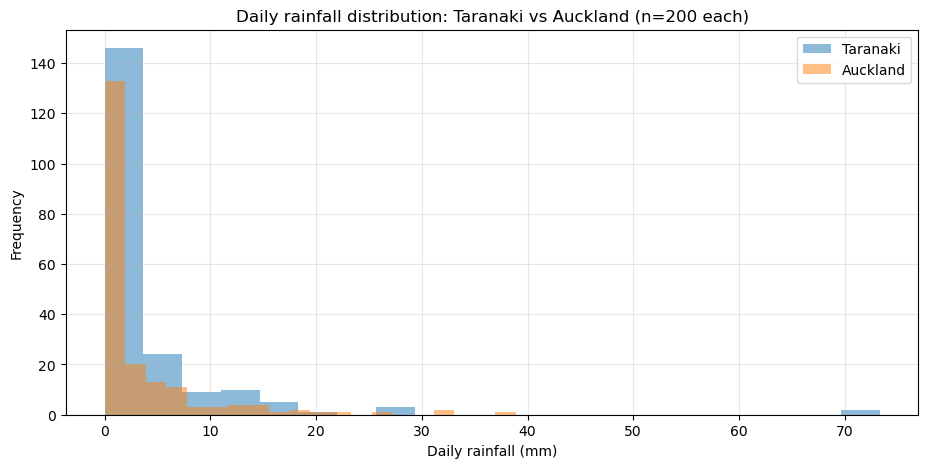

In [11]:
# Visualise the two distributions being compared
plt.hist(taranaki_rain, bins=20, alpha=0.5, label='Taranaki')
plt.hist(auckland_rain, bins=20, alpha=0.5, label='Auckland')
plt.xlabel('Daily rainfall (mm)')
plt.ylabel('Frequency')
plt.title(f'Daily rainfall distribution: Taranaki vs Auckland (n={N} each)')
plt.legend()
plt.show()

> **Finding (fill in once you see the result):** State whether the test rejected H0,
> and what that means in plain terms — either "Taranaki is significantly drier, so the
> regions aren't interchangeable" or "the difference isn't statistically significant,
> confirming how alike these regions are." Either result is a genuine finding.

### Axis 2 — Time vs time

Seasonal patterns and year-to-year variation. This is where drought years and wet years show up.

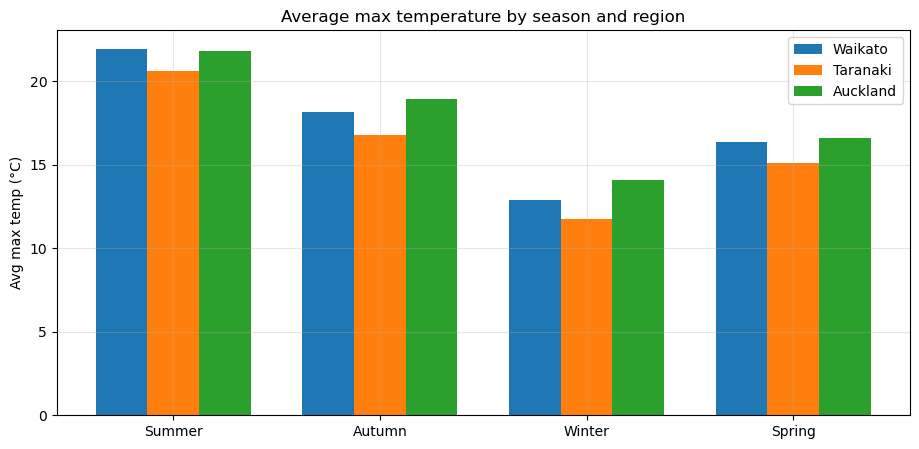

In [7]:
# Seasonal temperature pattern (max temp) per region
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
seasonal_temp = (weather.groupby(['region', 'season'])['temperature_2m_max']
                        .mean().reset_index())

fig, ax = plt.subplots()
width = 0.25
x = np.arange(len(season_order))
for i, name in enumerate(REGIONS):
    sub = seasonal_temp[seasonal_temp['region'] == name].set_index('season').reindex(season_order)
    ax.bar(x + i*width, sub['temperature_2m_max'], width, label=name)
ax.set_xticks(x + width)
ax.set_xticklabels(season_order)
ax.set_ylabel('Avg max temp (°C)')
ax.set_title('Average max temperature by season and region')
ax.legend()
plt.show()

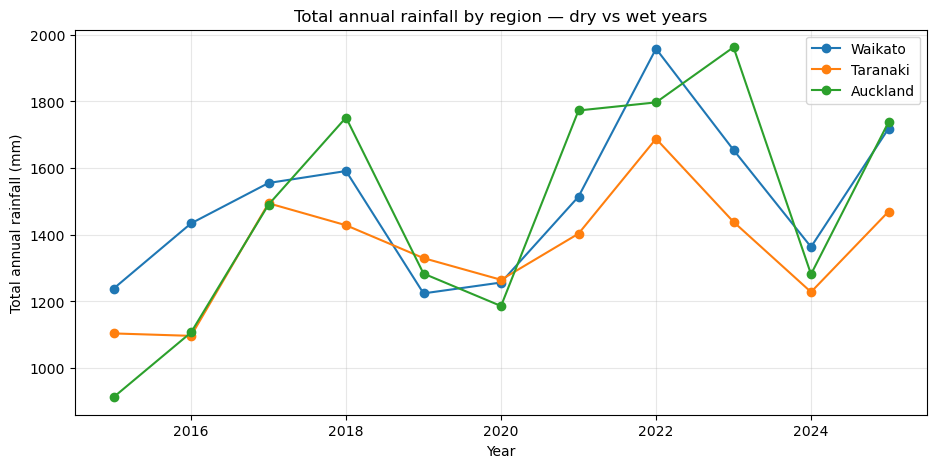

In [8]:
# Year-to-year total rainfall — spot the dry years and the wet years
annual_rain = (weather.groupby(['region', 'year'])['precipitation_sum']
                      .sum().reset_index())
# Drop partial years if 2026 is incomplete
full_years = annual_rain[annual_rain['year'] < weather['year'].max()]

fig, ax = plt.subplots()
for name in REGIONS:
    sub = full_years[full_years['region'] == name]
    ax.plot(sub['year'], sub['precipitation_sum'], marker='o', label=name)
ax.set_xlabel('Year')
ax.set_ylabel('Total annual rainfall (mm)')
ax.set_title('Total annual rainfall by region — dry vs wet years')
ax.legend()
plt.show()

> **Finding :** Clear year-to-year swings all three regions share: 2019–2020 were dry years across the board, 2022–2023 were wet. Auckland (green) is the most volatile — lowest in 2015, highest in 2022/2023. Taranaki consistently lowest in wet years

### Axis 3 — Variable vs variable

Relationships between the weather variables. The key one for pasture: rainfall (water in) vs ET0 (water demand out). When ET0 exceeds rainfall, the land is drying.

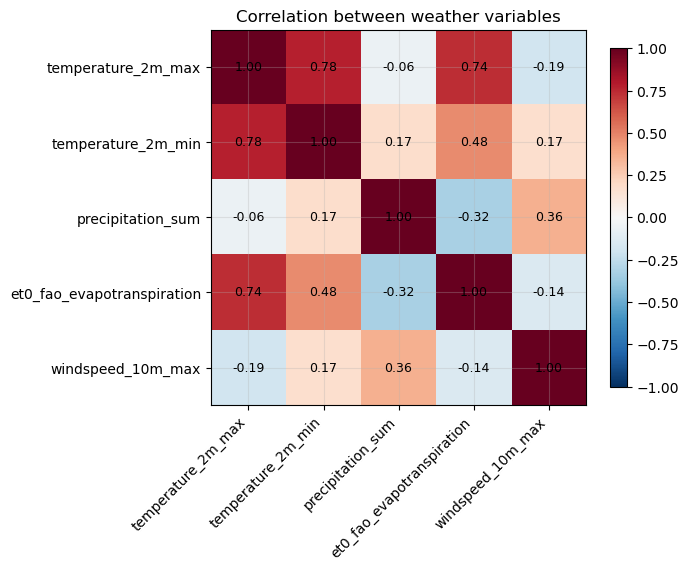

In [9]:
# Correlation matrix of the weather variables (all regions combined)
corr = weather[WEATHER_VARS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(WEATHER_VARS)))
ax.set_yticks(range(len(WEATHER_VARS)))
ax.set_xticklabels(WEATHER_VARS, rotation=45, ha='right')
ax.set_yticklabels(WEATHER_VARS)
for i in range(len(WEATHER_VARS)):
    for j in range(len(WEATHER_VARS)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation between weather variables')
plt.tight_layout()
plt.show()

> **Finding:** The data behaves the way physics says it should, which validates the dataset's integrity. Min and max temperature have a high corrolation (0.78). Evapotransipiration and precipitation have a negative corrolation (-0.32). Windspeed has the least corrolation with other variables. 

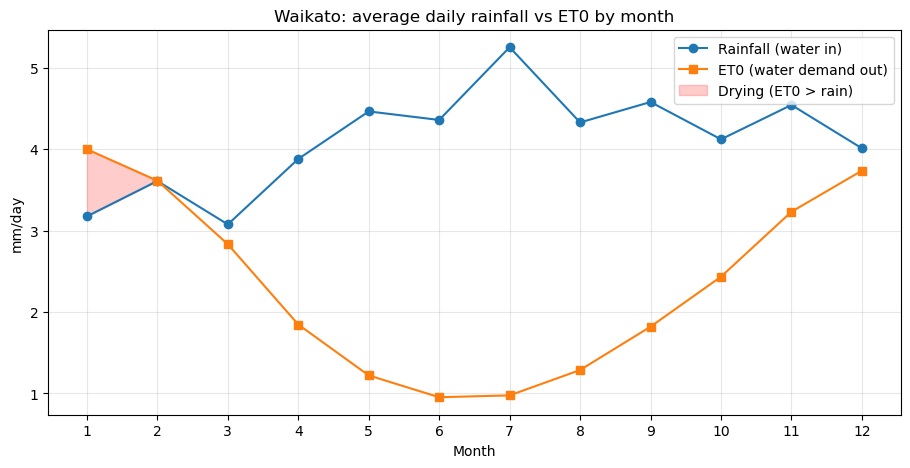

In [10]:
# Monthly rainfall vs ET0 for one region — the core pasture water-balance signal
focus = 'Waikato'
sub = weather[weather['region'] == focus]
monthly = sub.groupby('month')[['precipitation_sum', 'et0_fao_evapotranspiration']].mean()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly['precipitation_sum'], marker='o', label='Rainfall (water in)')
ax.plot(monthly.index, monthly['et0_fao_evapotranspiration'], marker='s', label='ET0 (water demand out)')
ax.fill_between(monthly.index, monthly['precipitation_sum'],
                monthly['et0_fao_evapotranspiration'],
                where=(monthly['et0_fao_evapotranspiration'] > monthly['precipitation_sum']),
                alpha=0.2, color='red', label='Drying (ET0 > rain)')
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('mm/day')
ax.set_title(f'{focus}: average daily rainfall vs ET0 by month')
ax.legend()
plt.show()

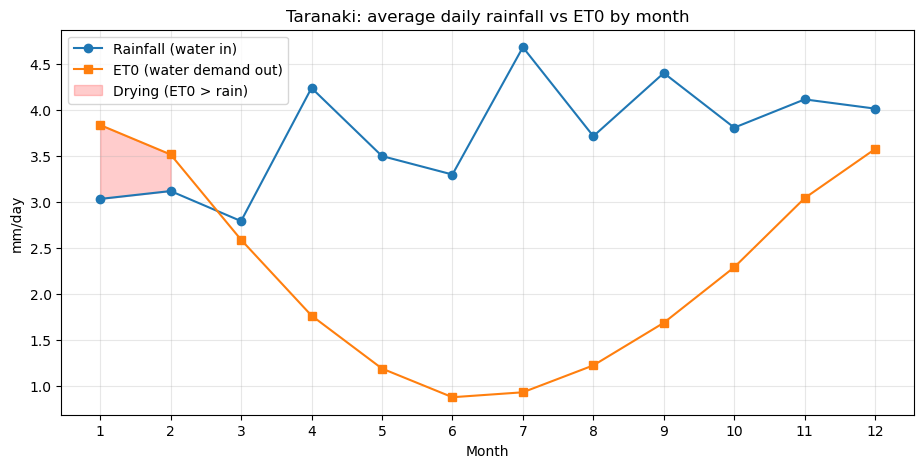

In [11]:
# Monthly rainfall vs ET0 for one region — the core pasture water-balance signal
focus = 'Taranaki'
sub = weather[weather['region'] == focus]
monthly = sub.groupby('month')[['precipitation_sum', 'et0_fao_evapotranspiration']].mean()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly['precipitation_sum'], marker='o', label='Rainfall (water in)')
ax.plot(monthly.index, monthly['et0_fao_evapotranspiration'], marker='s', label='ET0 (water demand out)')
ax.fill_between(monthly.index, monthly['precipitation_sum'],
                monthly['et0_fao_evapotranspiration'],
                where=(monthly['et0_fao_evapotranspiration'] > monthly['precipitation_sum']),
                alpha=0.2, color='red', label='Drying (ET0 > rain)')
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('mm/day')
ax.set_title(f'{focus}: average daily rainfall vs ET0 by month')
ax.legend()
plt.show()

> **Finding:** The red drying wedge appears only in mid-summer (months 1–2), where ET0 briefly exceeds rain. Waikato is rarely in true water deficit on these averages — but summer is the pinch point, exactly when pasture stress and feed tightening happen.
Taranaki has more varience in Rainfall and a slightly lrger drying range.

---
## Phase 3 — Feature engineering

Three agronomically meaningful features derived from the raw weather. These preview the pasture-growth model in the next phase — they are the inputs that drive grass growth.

1. **Growing Degree Days (GDD)** — accumulated warmth above a base temperature; a standard driver of plant growth.
2. **Rainfall deficit** — rainfall minus ET0; negative means the land is losing more water than it gains.
3. **Rolling ET0 (7-day)** — smooths daily noise to show sustained drying pressure.

> If the notebook is running long for the presentation, GDD alone is enough to satisfy the feature-engineering rubric — the other two can be cut.

In [19]:
BASE_TEMP = 5.0  # °C — common base for temperate pasture grasses

def add_features(df):
    df = df.sort_values('date').copy()
    # 1. Growing degree days: mean daily temp above base, floored at 0
    mean_temp = (df['temperature_2m_max'] + df['temperature_2m_min']) / 2
    df['gdd'] = (mean_temp - BASE_TEMP).clip(lower=0)
    # 2. Daily rainfall deficit (water in minus water demand)
    df['rain_deficit'] = df['precipitation_sum'] - df['et0_fao_evapotranspiration']
    # 3. 7-day rolling ET0 (sustained drying pressure)
    df['et0_7day'] = df['et0_fao_evapotranspiration'].rolling(7, min_periods=1).mean()
    return df

weather = (weather.groupby('region', group_keys=False).apply(add_features))
weather[['date', 'region', 'gdd', 'rain_deficit', 'et0_7day']].head()

C:\Users\Emily\AppData\Local\Temp\ipykernel_13200\2895927655.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weather = (weather.groupby('region', group_keys=False).apply(add_features))


,date,region,gdd,rain_deficit,et0_7day
0,2015-01-01,Waikato,12.40,0.77,4.830000
1,2015-01-02,Waikato,12.05,-3.57,4.200000
2,2015-01-03,Waikato,12.80,-4.50,4.366667
3,2015-01-04,Waikato,13.15,-4.20,4.400000
4,2015-01-05,Waikato,12.80,-5.06,4.532000


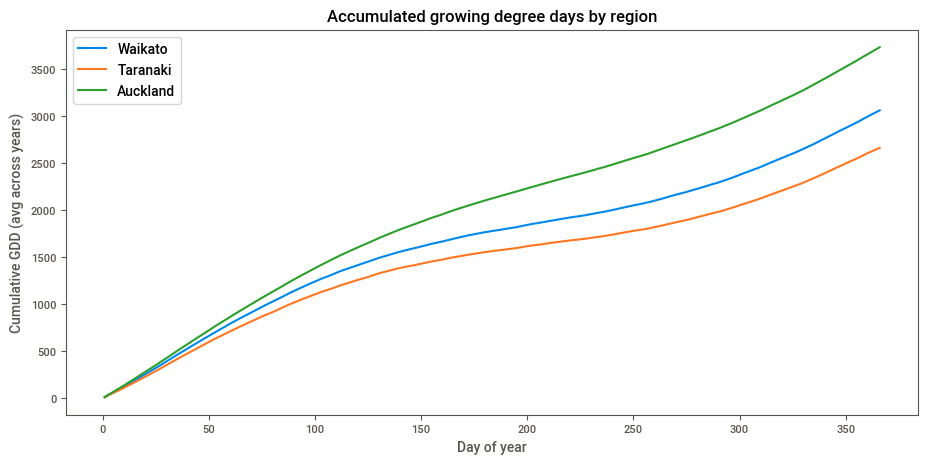

In [20]:
# Cumulative GDD through the year, per region — the warmth available for grass growth
weather['doy'] = weather['date'].dt.dayofyear
gdd_by_doy = (weather.groupby(['region', 'doy'])['gdd'].mean()
                     .groupby(level=0).cumsum().reset_index())

fig, ax = plt.subplots()
for name in REGIONS:
    sub = gdd_by_doy[gdd_by_doy['region'] == name]
    ax.plot(sub['doy'], sub['gdd'], label=name)
ax.set_xlabel('Day of year')
ax.set_ylabel('Cumulative GDD (avg across years)')
ax.set_title('Accumulated growing degree days by region')
ax.legend()
plt.show()

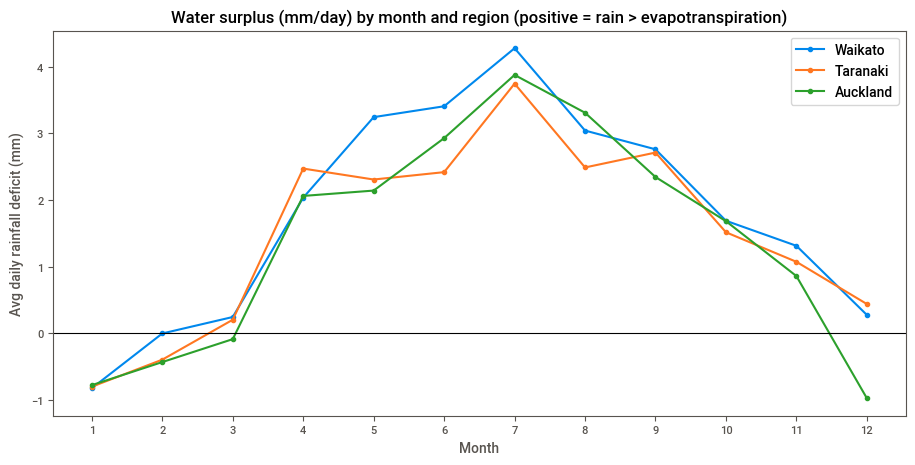

In [22]:
# Monthly average rainfall deficit per region — when is each region in water deficit?
monthly_deficit = (weather.groupby(['region', 'month'])['rain_deficit']
                          .mean().reset_index())

fig, ax = plt.subplots()
for name in REGIONS:
    sub = monthly_deficit[monthly_deficit['region'] == name]
    ax.plot(sub['month'], sub['rain_deficit'], marker='o', label=name)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Avg daily rainfall deficit (mm)')
ax.set_title('Water surplus (mm/day) by month and region (positive = rain > evapotranspiration)')
ax.legend()
plt.show()

> **Finding :** Auckland accumulates warmth fastest (green, top), Taranaki slowest (orange, bottom), Waikato between — consistent with the temperature chart. The curves fan apart over the year, so by year-end Auckland has ~3,700 GDD vs Taranaki ~2,650. Interpretation: Auckland has the longest effective growing window; Taranaki the shortest — meaning more potential pasture-growth days up north, a genuine region-level difference that matters for stocking

Sweetviz compare mode is pairwise, so pick two regions at a time.
It also doesn't need your calendar/feature helper columns for a weather profile
comparison, so drop the non-weather columns to keep the report focused.

In [15]:
import sweetviz as sv

# Sweetviz compare mode is pairwise, so pick two regions at a time.
# It also doesn't need your calendar/feature helper columns for a weather profile
# comparison, so drop the non-weather columns to keep the report focused.
cols = WEATHER_VARS + ['date']

waikato  = weather[weather['region'] == 'Waikato'][cols]
taranaki = weather[weather['region'] == 'Taranaki'][cols]

report = sv.compare(
    [waikato,  'Waikato'],
    [taranaki, 'Taranaki']
)
report.show_html('sweetviz_waikato_vs_taranaki.html')  # opens in your browser

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_waikato_vs_taranaki.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


---
## Phase 4 — Conclusion

This notebook set out to answer three questions. Here is what the data showed.

### Question 1 — How do the three regions differ, or are they the same?

The regions share a clear seasonal rhythm in rainfall, temperature, and
drying, but differ in magnitude: Taranaki runs consistently coolest and driest, Auckland
warmest with the longest growing window, Waikato between the two. The hypothesis test in
Phase 2 did not confirm that the Taranaki–Auckland rainfall difference is
statistically significant (p = 0.4688), which means the regions are statistically alike, validating the decision
to treat them as one North Island profile.

### Question 2 — When does each region come under water stress?

Water demand (ET0) follows a strong seasonal cycle, peaking in summer and
bottoming out in winter, while rainfall stays comparatively flat year-round. The result is
a summer pinch: in months one and two the land's water demand approaches or exceeds supply, which
is exactly when pasture growth slows and feed gets tight. This is the core signal PastureIQ
is built to flag.

### Question 3 — Are dry years local or shared?

The annual rainfall comparison showed the three regions moving together year
to year: the dry years 2015 and 2020 and wet years 2022 and 2025 are shared across all three. Drought is a
regional event, not a local one — so feed pressure tends to arrive across the whole North
Island at once, something the tool must anticipate.

### What the engineered features set up

The features built here — growing degree days (accumulated warmth), water surplus (rainfall
minus ET0), and rolling ET0 (sustained drying) — are the weather signals that actually drive
grass growth. They are the inputs to the next phase.

### Where this goes next

- **MP2:** Connect this weather foundation to a pasture-growth model (weather → kg DM/ha/day),
  and combine it with mob feed demand to produce a pasture-balance signal.
- **MP3:** Add market-price forecasting and produce the plain-English buy/sell recommendation
  that is PastureIQ's end goal.

This notebook establishes that the weather data is complete, regionally characterised, and
carries the seasonal drying signals that drive pasture — the necessary groundwork before any
of that can be modelled.

---